<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/OnStructuralStabilityNS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

se-CJM v5.9
Navier-Stokes Atemporal Structural Persistence
Physical system         : 3D incompressible Navier-Stokes
Initial condition       : Taylor-Green vortex
Grid                    : 20^3
Snapshot time           : 4.0
Re range                : 50.0 - 400.0
CJM trajectory input    : NONE
CJM previous-time input : NONE
STEP 2 modification     : NONE
Structural readout      : M_J, D_J, F_J + full E texture
Hypercomputation claim  : NONE

[Independent snapshot 1/15] Re = 50.0
[Independent snapshot 2/15] Re = 75.0
[Independent snapshot 3/15] Re = 100.0
[Independent snapshot 4/15] Re = 125.0
[Independent snapshot 5/15] Re = 150.0
[Independent snapshot 6/15] Re = 175.0
[Independent snapshot 7/15] Re = 200.0
[Independent snapshot 8/15] Re = 225.0
[Independent snapshot 9/15] Re = 250.0
[Independent snapshot 10/15] Re = 275.0
[Independent snapshot 11/15] Re = 300.0
[Independent snapshot 12/15] Re = 325.0
[Independent snapshot 13/15] Re = 350.0
[Independent snapshot 14/15] Re = 375.0
[Indep

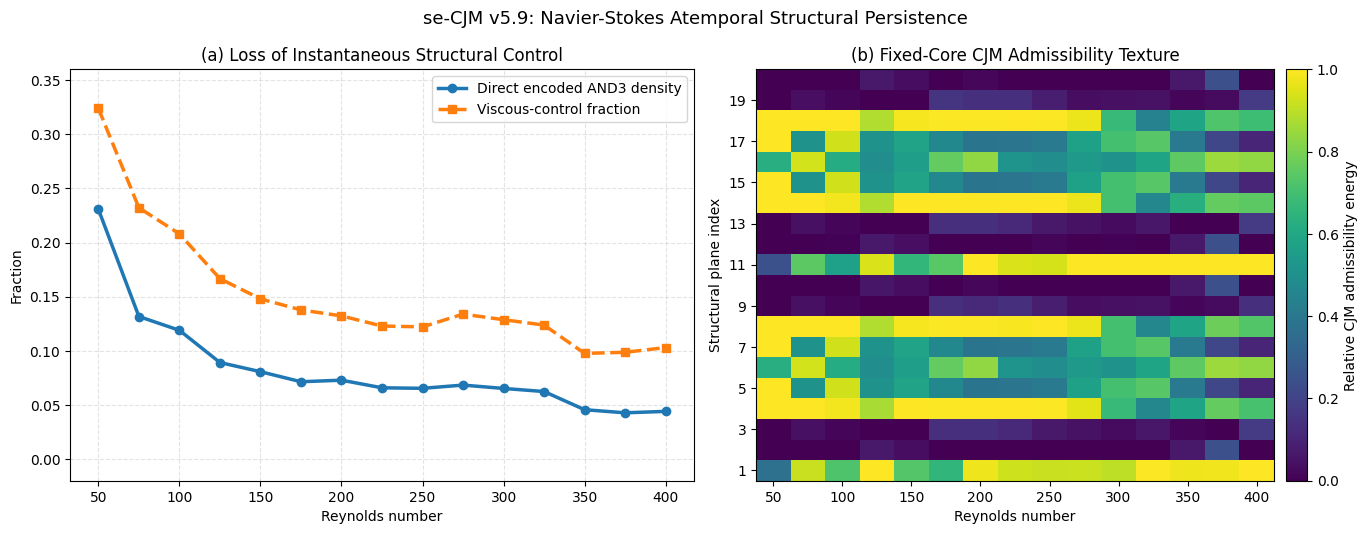


RESULT SUMMARY
M_J = mean(E) range     : 0.3801 - 0.5123
D_J = std(E) range      : 0.3275 - 0.4525
F_J fragmentation range : 0.2000 - 0.8000
encoded AND3 range      : 0.0427 - 0.2307
viscous-control range   : 0.0976 - 0.3239
Critical point planted  : NO
Synthetic input         : NO
Sequential CJM input    : NO
STEP-2 retuning         : NO
Singularity claim       : NONE
Runtime                 : 24.7 seconds
Saved figure            : secjm_v59_navier_atemporal_texture.png


[{'Re': 50.0,
  'J_mean': 0.4940644689279006,
  'D_J': 0.45253898497180384,
  'F_J_count': 4,
  'F_J': 0.2,
  'energy_median': 0.4987336560127002,
  'raw_density': 0.2307142857142857,
  'enstrophy': 0.36140104332255635,
  'omega_max': 1.822196858611924,
  'high_k': 0.03381923818808271,
  'positive_stretch': 0.594125,
  'viscous_control': 0.323875,
  'energy': array([3.69537724e-01, 3.02883910e-04, 2.73191401e-03, 9.98851679e-01,
         1.00000000e+00, 6.27929588e-01, 1.00000000e+00, 9.98851679e-01,
         2.73191401e-03, 0.00000000e+00, 2.48649457e-01, 3.02883910e-04,
         2.73191401e-03, 9.98851679e-01, 1.00000000e+00, 6.27929588e-01,
         1.00000000e+00, 9.98851679e-01, 2.73191401e-03, 3.02883910e-04])},
 {'Re': 75.0,
  'J_mean': 0.48606367827879005,
  'D_J': 0.4155783262612654,
  'F_J_count': 16,
  'F_J': 0.8,
  'energy_median': 0.5084944542229429,
  'raw_density': 0.13166666666666665,
  'enstrophy': 0.5062010527161717,
  'omega_max': 2.3828755118846536,
  'high_k': 0.05

In [ ]:
# ============================================================
# Appendix 1: Python Code for Navier-Stokes Figure (se-CJM v5.9)
# ============================================================
# se-CJM (software-emulated CJM) implements a 4-step pipeline:
#   (1) Navier-Stokes snapshot embedding -> logic-like literals (x1, x2)
#   (2) CJM core engine                  -> plane-wise admissibility energy
#   (3) Structural readout              -> dispersion and fragmentation
#   (4) Visualization                   -> physical loss + CJM texture map
#
# This appendix presents the primary Navier-Stokes snapshot scan
# used in Figure 1. Each Reynolds-number case is evaluated from one
# static flow state u(x,t0), while the CJM discrimination stage does
# not use previous or future flow states.
#
# Unlike the earlier scalar visualization, the present figure retains
# the full STEP-2 output vector across structural planes. The resulting
# texture map is used to visualize changes in internal admissibility
# organization rather than reducing each snapshot to a single mean.
#
# The texture is not interpreted as evidence of singularity or
# finite-time blow-up. It is used only as a structural visualization
# of how a fixed CJM core organizes independent Navier-Stokes snapshots.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time

TINY = 1e-12


# ==========================================
# User settings
# ==========================================
N = 20

RE_VALUES = np.arange(50.0, 401.0, 25.0)

SNAPSHOT_TIME = 4.0
DT = 0.02

# Universal CJM core settings -- fixed across this scan
CJM_GATE = "AND3"
CJM_BETA = 34.0
CJM_MODE = "logistic"

SAVE_PATH = "secjm_v59_navier_atemporal_texture.png"


# ==========================================
# Utility normalization
# ==========================================
def normalize01(y):
    """
    Normalize an array to [0,1] for visualization.
    """
    y = np.asarray(y, dtype=float)

    return (
        (y - np.min(y))
        /
        (np.max(y) - np.min(y) + TINY)
    )


# ==========================================
# Fourier grid for periodic Navier-Stokes flow
# ==========================================
def make_spectral_grid(N):
    """
    Construct the Fourier grid on the periodic domain [0,2pi]^3.

    Returns:
      KX, KY, KZ : wave-number grids
      K2         : squared wave-number magnitude
      K2_SAFE    : zero-safe K2
      K_MAG      : wave-number magnitude
      DEALIAS    : 2/3-rule dealiasing mask
      K_CUT      : dealiased cutoff
    """
    k = np.fft.fftfreq(N, d=1.0 / N)

    KX, KY, KZ = np.meshgrid(
        k, k, k,
        indexing="ij"
    )

    K2 = (
        KX**2
        +
        KY**2
        +
        KZ**2
    )

    K2_SAFE = K2.copy()
    K2_SAFE[0, 0, 0] = 1.0

    K_MAG = np.sqrt(K2)

    K_CUT = N // 3

    DEALIAS = (
        (np.abs(KX) <= K_CUT)
        &
        (np.abs(KY) <= K_CUT)
        &
        (np.abs(KZ) <= K_CUT)
    )

    return (
        KX, KY, KZ,
        K2, K2_SAFE,
        K_MAG,
        DEALIAS,
        K_CUT
    )


# ==========================================
# Divergence-free Fourier projection
# ==========================================
def project_divergence_free(
    u_hat,
    KX,
    KY,
    KZ,
    K2_SAFE
):
    """
    Apply the Fourier-space Leray projection.

    This enforces the incompressibility condition

        div u = 0.
    """
    k_dot_u = (
        KX * u_hat[0]
        +
        KY * u_hat[1]
        +
        KZ * u_hat[2]
    )

    out = u_hat.copy()

    out[0] -= KX * k_dot_u / K2_SAFE
    out[1] -= KY * k_dot_u / K2_SAFE
    out[2] -= KZ * k_dot_u / K2_SAFE

    # Remove the mean-velocity mode
    out[:, 0, 0, 0] = 0.0

    return out


# ==========================================
# Taylor-Green initial condition
# ==========================================
def taylor_green_initial_condition(
    N,
    KX,
    KY,
    KZ,
    K2_SAFE,
    DEALIAS
):
    """
    Standard three-dimensional Taylor-Green vortex:

      u =  sin(x) cos(y) cos(z)
      v = -cos(x) sin(y) cos(z)
      w =  0

    The field is projected and dealiased before integration.
    """
    x = 2.0 * np.pi * np.arange(N) / N

    X, Y, Z = np.meshgrid(
        x, x, x,
        indexing="ij"
    )

    u = np.zeros(
        (3, N, N, N),
        dtype=float
    )

    u[0] = (
        np.sin(X)
        *
        np.cos(Y)
        *
        np.cos(Z)
    )

    u[1] = (
        -np.cos(X)
        *
        np.sin(Y)
        *
        np.cos(Z)
    )

    u[2] = 0.0

    u_hat = np.fft.fftn(
        u,
        axes=(1, 2, 3)
    )

    u_hat = project_divergence_free(
        u_hat,
        KX,
        KY,
        KZ,
        K2_SAFE
    )

    u_hat *= DEALIAS[None, :, :, :]

    return u_hat


# ==========================================
# Spectral vorticity
# ==========================================
def curl_hat(
    u_hat,
    KX,
    KY,
    KZ
):
    """
    Compute Fourier-space vorticity

        omega_hat = i k x u_hat.
    """
    omega_hat = np.empty_like(u_hat)

    omega_hat[0] = (
        1j
        *
        (
            KY * u_hat[2]
            -
            KZ * u_hat[1]
        )
    )

    omega_hat[1] = (
        1j
        *
        (
            KZ * u_hat[0]
            -
            KX * u_hat[2]
        )
    )

    omega_hat[2] = (
        1j
        *
        (
            KX * u_hat[1]
            -
            KY * u_hat[0]
        )
    )

    return omega_hat


# ==========================================
# Navier-Stokes nonlinear term
# ==========================================
def nonlinear_term_hat(
    u_hat,
    KX,
    KY,
    KZ,
    K2_SAFE,
    DEALIAS
):
    """
    Evaluate the projected rotational nonlinear term

        P(u x omega).

    The resulting field is dealiased and projected.
    """
    omega_hat = curl_hat(
        u_hat,
        KX,
        KY,
        KZ
    )

    u = np.fft.ifftn(
        u_hat,
        axes=(1, 2, 3)
    ).real

    omega = np.fft.ifftn(
        omega_hat,
        axes=(1, 2, 3)
    ).real

    cross = np.empty_like(u)

    cross[0] = (
        u[1] * omega[2]
        -
        u[2] * omega[1]
    )

    cross[1] = (
        u[2] * omega[0]
        -
        u[0] * omega[2]
    )

    cross[2] = (
        u[0] * omega[1]
        -
        u[1] * omega[0]
    )

    nonlinear_hat = np.fft.fftn(
        cross,
        axes=(1, 2, 3)
    )

    nonlinear_hat *= DEALIAS[None, :, :, :]

    nonlinear_hat = project_divergence_free(
        nonlinear_hat,
        KX,
        KY,
        KZ,
        K2_SAFE
    )

    return nonlinear_hat


# ==========================================
# Navier-Stokes right-hand side
# ==========================================
def navier_stokes_rhs(
    u_hat,
    nu,
    KX,
    KY,
    KZ,
    K2,
    K2_SAFE,
    DEALIAS
):
    """
    Evaluate the Fourier-space Navier-Stokes right-hand side:

        du/dt = P(u x omega) - nu k^2 u.
    """
    nonlinear_hat = nonlinear_term_hat(
        u_hat,
        KX,
        KY,
        KZ,
        K2_SAFE,
        DEALIAS
    )

    viscous_hat = (
        -nu
        *
        K2[None, :, :, :]
        *
        u_hat
    )

    return (
        nonlinear_hat
        +
        viscous_hat
    )


# ==========================================
# SSP-RK3 time integrator
# ==========================================
def rk3_step(
    u_hat,
    dt,
    nu,
    KX,
    KY,
    KZ,
    K2,
    K2_SAFE,
    DEALIAS
):
    """
    Advance one conventional Navier-Stokes integration step
    using a three-stage SSP-RK3 scheme.
    """
    # Stage 1
    f0 = navier_stokes_rhs(
        u_hat,
        nu,
        KX,
        KY,
        KZ,
        K2,
        K2_SAFE,
        DEALIAS
    )

    u1 = (
        u_hat
        +
        dt * f0
    )

    u1 = project_divergence_free(
        u1,
        KX,
        KY,
        KZ,
        K2_SAFE
    )

    u1 *= DEALIAS[None, :, :, :]

    # Stage 2
    f1 = navier_stokes_rhs(
        u1,
        nu,
        KX,
        KY,
        KZ,
        K2,
        K2_SAFE,
        DEALIAS
    )

    u2 = (
        0.75 * u_hat
        +
        0.25
        *
        (
            u1
            +
            dt * f1
        )
    )

    u2 = project_divergence_free(
        u2,
        KX,
        KY,
        KZ,
        K2_SAFE
    )

    u2 *= DEALIAS[None, :, :, :]

    # Stage 3
    f2 = navier_stokes_rhs(
        u2,
        nu,
        KX,
        KY,
        KZ,
        K2,
        K2_SAFE,
        DEALIAS
    )

    u_new = (
        (1.0 / 3.0) * u_hat
        +
        (2.0 / 3.0)
        *
        (
            u2
            +
            dt * f2
        )
    )

    u_new = project_divergence_free(
        u_new,
        KX,
        KY,
        KZ,
        K2_SAFE
    )

    u_new *= DEALIAS[None, :, :, :]

    return u_new


# ==========================================
# Static physical snapshot generation
# ==========================================
def generate_snapshot(
    Re,
    grid
):
    """
    Generate one Navier-Stokes state u(x,t0) for a given Reynolds number.

    Conventional temporal integration is used only to generate the
    reference physical snapshot.

    No intermediate flow state is sent to the CJM discrimination stage.
    """
    (
        KX, KY, KZ,
        K2, K2_SAFE,
        K_MAG,
        DEALIAS,
        K_CUT
    ) = grid

    nu = 1.0 / Re

    u_hat = taylor_green_initial_condition(
        N,
        KX,
        KY,
        KZ,
        K2_SAFE,
        DEALIAS
    )

    n_steps = int(
        np.round(
            SNAPSHOT_TIME / DT
        )
    )

    for _ in range(n_steps):
        u_hat = rk3_step(
            u_hat,
            DT,
            nu,
            KX,
            KY,
            KZ,
            K2,
            K2_SAFE,
            DEALIAS
        )

    return u_hat, nu


# ==========================================
# Snapshot structural quantities
# ==========================================
def snapshot_structural_fields(
    u_hat,
    nu,
    grid
):
    """
    Extract instantaneous structural quantities from one static snapshot.

    Primary fields:
      - vortex stretching: omega . S . omega
      - viscous structural proxy: nu |grad omega|^2

    Additional diagnostics:
      - enstrophy
      - maximum vorticity
      - high-k energy fraction
      - positive-stretch fraction
      - viscous-control fraction

    Note:
      nu |grad omega|^2 is used as a positive local structural proxy
      for viscous enstrophy loss. Pointwise, it is not identical to

          nu omega . Delta omega.

      On a periodic domain,

          integral omega . Delta omega dV
            = - integral |grad omega|^2 dV.

      The local comparison used here is therefore a structural
      heuristic rather than an exact pointwise enstrophy balance.
    """
    (
        KX, KY, KZ,
        K2, K2_SAFE,
        K_MAG,
        DEALIAS,
        K_CUT
    ) = grid

    Ks = [
        KX,
        KY,
        KZ
    ]

    omega_hat = curl_hat(
        u_hat,
        KX,
        KY,
        KZ
    )

    omega = np.fft.ifftn(
        omega_hat,
        axes=(1, 2, 3)
    ).real

    # Velocity-gradient tensor
    grad_u = np.empty(
        (3, 3, N, N, N),
        dtype=float
    )

    for i in range(3):
        for j in range(3):
            grad_u[i, j] = np.fft.ifftn(
                1j
                *
                Ks[j]
                *
                u_hat[i]
            ).real

    # Strain tensor
    strain = (
        0.5
        *
        (
            grad_u
            +
            np.swapaxes(
                grad_u,
                0,
                1
            )
        )
    )

    # Vortex stretching: omega . S . omega
    S_omega = np.einsum(
        "ijxyz,jxyz->ixyz",
        strain,
        omega,
        optimize=True
    )

    stretching = np.sum(
        omega
        *
        S_omega,
        axis=0
    )

    # Vorticity-gradient tensor
    grad_omega = np.empty(
        (3, 3, N, N, N),
        dtype=float
    )

    for i in range(3):
        for j in range(3):
            grad_omega[i, j] = np.fft.ifftn(
                1j
                *
                Ks[j]
                *
                omega_hat[i]
            ).real

    # Positive viscous structural proxy
    viscous_dissipation = (
        nu
        *
        np.sum(
            grad_omega
            *
            grad_omega,
            axis=(0, 1)
        )
    )

    # Enstrophy and maximum vorticity
    omega_sq = np.sum(
        omega
        *
        omega,
        axis=0
    )

    enstrophy = (
        0.5
        *
        np.mean(
            omega_sq
        )
    )

    omega_max = np.max(
        np.sqrt(
            omega_sq
        )
    )

    # High-wave-number energy fraction
    spectral_energy = np.sum(
        np.abs(u_hat) ** 2,
        axis=0
    )

    sphere_mask = (
        DEALIAS
        &
        (K_MAG <= K_CUT)
    )

    high_mask = (
        sphere_mask
        &
        (
            K_MAG
            >=
            0.65 * K_CUT
        )
    )

    high_k_fraction = (
        np.sum(
            spectral_energy[
                high_mask
            ]
        )
        /
        (
            np.sum(
                spectral_energy[
                    sphere_mask
                ]
            )
            +
            TINY
        )
    )

    positive_stretch_fraction = np.mean(
        stretching > 0.0
    )

    viscous_control_fraction = np.mean(
        (stretching > 0.0)
        &
        (
            viscous_dissipation
            >=
            stretching
        )
    )

    return {
        "stretching": stretching,
        "viscous_dissipation": viscous_dissipation,
        "enstrophy": float(enstrophy),
        "omega_max": float(omega_max),
        "high_k": float(high_k_fraction),
        "positive_stretch_fraction": float(positive_stretch_fraction),
        "viscous_control_fraction": float(viscous_control_fraction),
    }


# ==========================================
# STEP 1: INPUT MODULE (Navier-Stokes snapshot embedding)
# ==========================================
def snapshot_to_literal_matrix(
    stretching,
    viscous_dissipation
):
    """
    Convert one static Navier-Stokes snapshot into literals x1, x2.

    Interpretation:
      - x1 = 1 for positive local vortex stretching
      - x2 = 1 where the viscous structural proxy is at least as
             large as the positive stretching term
      - axis 0 is spatial ordering, not time
      - columns represent z-planes of the same static snapshot

    A zero spacer separates neighboring y-rows so STEP 2's x1_prev
    coupling does not cross artificial row boundaries.

    Note:
      The present encoding uses x-direction spatial adjacency.
      This directional choice is an encoding decision and should be
      tested against equivalent y- and z-direction encodings later.
    """
    x1_columns = []
    x2_columns = []

    for z in range(N):
        x1_rows = []
        x2_rows = []

        for y in range(N):
            local_stretch = stretching[:, y, z]
            local_viscous = viscous_dissipation[:, y, z]

            # x1: positive vortex-stretching event
            x1_line = (
                local_stretch > 0.0
            ).astype(np.uint8)

            # x2: local viscous-control heuristic
            x2_line = (
                local_viscous
                >=
                np.maximum(
                    local_stretch,
                    0.0
                )
            ).astype(np.uint8)

            x1_rows.extend(
                x1_line.tolist()
            )

            x2_rows.extend(
                x2_line.tolist()
            )

            # Spacer prevents artificial row-to-row adjacency
            x1_rows.append(0)
            x2_rows.append(0)

        x1_columns.append(x1_rows)
        x2_columns.append(x2_rows)

    x1 = np.asarray(
        x1_columns,
        dtype=np.uint8
    ).T

    x2 = np.asarray(
        x2_columns,
        dtype=np.uint8
    ).T

    return x1, x2


# ==========================================
# STEP 2: CJM CORE ENGINE (kept reusable)
# ==========================================
def step2_cjm_core_engine(
    x1,
    x2,
    gate="AND3",
    beta=34.0,
    mode="logistic"
):
    """
    Universal CJM core engine.

    A. 3-literal clause interaction
       clauses_i = f(x1_i, x2_i, x1_{i-1})

    B. plane-wise admissibility density
       mean over the spatial structural axis

    C. Contrast mapping
       normalized energy in [0,1]

    This function is kept unchanged.
    """
    x1_prev = np.roll(
        x1,
        shift=1,
        axis=0
    )

    x1_prev[0, :] = 0

    if gate == "MAJ":
        clauses = (
            (x1 + x2 + x1_prev) >= 2
        ).astype(np.uint8)

    elif gate == "AND3":
        clauses = (
            x1
            &
            x2
            &
            x1_prev
        ).astype(np.uint8)

    else:
        clauses = (
            x1
            |
            x2
            |
            x1_prev
        ).astype(np.uint8)

    sat_density = clauses.mean(
        axis=0
    )

    if mode == "zscore":
        z = (
            sat_density
            -
            sat_density.mean()
        ) / (
            sat_density.std()
            +
            TINY
        )

        energy = (
            1
            /
            (
                1
                +
                np.exp(-z)
            )
        )

    else:
        center = np.median(
            sat_density
        )

        energy = (
            1
            /
            (
                1
                +
                np.exp(
                    -beta
                    *
                    (
                        sat_density
                        -
                        center
                    )
                )
            )
        )

    energy = (
        energy
        -
        energy.min()
    ) / (
        energy.max()
        -
        energy.min()
        +
        TINY
    )

    return energy


# ==========================================
# STEP 3: Structural readout
# ==========================================
def evaluate_one_snapshot(
    Re,
    grid
):
    """
    Evaluate one independent Navier-Stokes snapshot.

    Pipeline:
      1) generate u(x,t0)
      2) extract instantaneous structural fields
      3) construct x1, x2
      4) evaluate the fixed CJM core
      5) retain the full energy vector E

    Structural readouts:
      M_J = mean(E)
      D_J = std(E)
      F_J = periodic median-crossing fragmentation rate

    The complete vector E is retained for the texture map in Figure 1.
    """
    u_hat, nu = generate_snapshot(
        Re,
        grid
    )

    fields = snapshot_structural_fields(
        u_hat,
        nu,
        grid
    )

    x1, x2 = snapshot_to_literal_matrix(
        fields["stretching"],
        fields["viscous_dissipation"]
    )

    # STEP 2
    energy = step2_cjm_core_engine(
        x1,
        x2,
        gate=CJM_GATE,
        beta=CJM_BETA,
        mode=CJM_MODE
    )

    # Mean response
    J_mean = float(
        np.mean(
            energy
        )
    )

    # Structural dispersion
    D_J = float(
        np.std(
            energy
        )
    )

    # Periodic median-crossing fragmentation
    energy_median = float(
        np.median(
            energy
        )
    )

    above_median = (
        energy
        >
        energy_median
    )

    fragmentation_count = int(
        np.sum(
            above_median
            !=
            np.roll(
                above_median,
                shift=1
            )
        )
    )

    fragmentation_rate = float(
        fragmentation_count
        /
        max(
            1,
            len(energy)
        )
    )

    # Direct encoded AND3 density before STEP 2 contrast mapping
    x1_prev = np.roll(
        x1,
        shift=1,
        axis=0
    )

    x1_prev[0, :] = 0

    direct_clauses = (
        x1
        &
        x2
        &
        x1_prev
    ).astype(np.uint8)

    raw_density = float(
        np.mean(
            direct_clauses
        )
    )

    return {
        "Re": float(Re),
        "J_mean": J_mean,
        "D_J": D_J,
        "F_J_count": fragmentation_count,
        "F_J": fragmentation_rate,
        "energy_median": energy_median,
        "raw_density": raw_density,
        "enstrophy": fields["enstrophy"],
        "omega_max": fields["omega_max"],
        "high_k": fields["high_k"],
        "positive_stretch": fields["positive_stretch_fraction"],
        "viscous_control": fields["viscous_control_fraction"],
        "energy": energy,
    }


# ==========================================
# Independent Reynolds-number snapshot sweep
# ==========================================
def step3_independent_snapshot_sweep():
    """
    Evaluate each Reynolds-number state independently.

    The CJM evaluation for Re_i does not require the CJM result
    of Re_(i-1), Re_(i+1), or any earlier flow state.
    """
    grid = make_spectral_grid(N)

    results = []

    for index, Re in enumerate(RE_VALUES):
        print(
            f"[Independent snapshot "
            f"{index + 1}/{len(RE_VALUES)}] "
            f"Re = {Re:.1f}"
        )

        result = evaluate_one_snapshot(
            Re,
            grid
        )

        results.append(
            result
        )

    return results


# ==========================================
# Reynolds-number cell edges for heatmap
# ==========================================
def parameter_edges(values):
    """
    Construct plotting-cell edges around an ordered parameter array.
    """
    values = np.asarray(
        values,
        dtype=float
    )

    if len(values) == 1:
        return np.asarray(
            [
                values[0] - 0.5,
                values[0] + 0.5
            ]
        )

    mid = (
        values[:-1]
        +
        values[1:]
    ) / 2.0

    first = (
        values[0]
        -
        (
            values[1]
            -
            values[0]
        ) / 2.0
    )

    last = (
        values[-1]
        +
        (
            values[-1]
            -
            values[-2]
        ) / 2.0
    )

    return np.concatenate(
        (
            [first],
            mid,
            [last]
        )
    )


# ==========================================
# STEP 4: Visualization
# ==========================================
def step4_plot(results):
    """
    Plot the Navier-Stokes structural persistence figure.

    Panel (a):
      direct encoded AND3 density and physical viscous-control fraction

    Panel (b):
      complete STEP-2 admissibility-energy texture across independent
      Reynolds-number snapshots and structural z-planes

    Note:
      STEP 2 normalizes each snapshot internally. Heatmap colors
      therefore represent within-snapshot structural organization,
      not an absolute energy magnitude shared across Reynolds numbers.
    """
    Re = np.asarray(
        [r["Re"] for r in results]
    )

    raw = np.asarray(
        [r["raw_density"] for r in results]
    )

    viscous_control = np.asarray(
        [r["viscous_control"] for r in results]
    )

    # Complete STEP-2 energy vectors
    energy_matrix = np.stack(
        [
            r["energy"]
            for r in results
        ],
        axis=1
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.4)
    )

    # -------------------- PANEL (a) --------------------
    ax = axes[0]

    # Both quantities are fractions in [0,1],
    # so they are shown on their original scale.
    ax.plot(
        Re,
        raw,
        linewidth=2.5,
        marker="o",
        label="Direct encoded AND3 density"
    )

    ax.plot(
        Re,
        viscous_control,
        linewidth=2.5,
        linestyle="--",
        marker="s",
        label="Viscous-control fraction"
    )

    ax.set_title(
        "(a) Loss of Instantaneous Structural Control"
    )

    ax.set_xlabel(
        "Reynolds number"
    )

    ax.set_ylabel(
        "Fraction"
    )

    ax.set_ylim(
        -0.02,
        max(
            0.36,
            1.10
            *
            max(
                np.max(raw),
                np.max(viscous_control)
            )
        )
    )

    ax.grid(
        linestyle="--",
        alpha=0.35
    )

    ax.legend()

    # -------------------- PANEL (b) --------------------
    ax = axes[1]

    re_edges = parameter_edges(
        Re
    )

    plane_edges = np.arange(
        0.5,
        N + 1.5,
        1.0
    )

    texture = ax.pcolormesh(
        re_edges,
        plane_edges,
        energy_matrix,
        shading="flat",
        vmin=0.0,
        vmax=1.0
    )

    ax.set_title(
        "(b) Fixed-Core CJM Admissibility Texture"
    )

    ax.set_xlabel(
        "Reynolds number"
    )

    ax.set_ylabel(
        "Structural plane index"
    )

    ax.set_yticks(
        np.arange(
            1,
            N + 1,
            2
        )
    )

    # Colorbar shows relative within-snapshot organization
    cbar = fig.colorbar(
        texture,
        ax=ax,
        pad=0.02
    )

    cbar.set_label(
        "Relative CJM admissibility energy"
    )

    fig.suptitle(
        "se-CJM v5.9: "
        "Navier-Stokes Atemporal Structural Persistence",
        fontsize=13
    )

    fig.tight_layout()

    fig.savefig(
        SAVE_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================
# MASTER CONTROL (se-CJM v5.9-Navier)
# ==========================================
# Each Reynolds-number case is generated conventionally to one
# static snapshot u(x,t0), after which CJM evaluation is performed
# independently without sequential trajectory input.
#
# Atemporal discrimination here means removal of trajectory
# dependence from the CJM evaluation stage. It does not imply
# hypercomputation or computation beyond the Turing framework.
# ==========================================
def run_secjm_v59():
    """
    Runs the se-CJM v5.9 Navier-Stokes pipeline:
      1) static Navier-Stokes snapshot -> x1, x2
      2) fixed CJM core -> energy vector E
      3) structural readout -> M_J, D_J, F_J
      4) plot physical loss and CJM admissibility texture

    Note:
      The experiment is a finite numerical structural probe.
      No singularity or global-regularity result is claimed.
    """
    start = time.time()

    print("=" * 60)
    print("se-CJM v5.9")
    print("Navier-Stokes Atemporal Structural Persistence")
    print("=" * 60)

    print(
        "Physical system         : "
        "3D incompressible Navier-Stokes"
    )

    print(
        "Initial condition       : "
        "Taylor-Green vortex"
    )

    print(
        f"Grid                    : "
        f"{N}^3"
    )

    print(
        f"Snapshot time           : "
        f"{SNAPSHOT_TIME}"
    )

    print(
        f"Re range                : "
        f"{RE_VALUES[0]:.1f} - {RE_VALUES[-1]:.1f}"
    )

    print(
        "CJM trajectory input    : NONE"
    )

    print(
        "CJM previous-time input : NONE"
    )

    print(
        "STEP 2 modification     : NONE"
    )

    print(
        "Structural readout      : M_J, D_J, F_J + full E texture"
    )

    print(
        "Hypercomputation claim  : NONE"
    )

    print("=" * 60)
    print()

    # STEP 1-3
    results = step3_independent_snapshot_sweep()

    # STEP 4
    step4_plot(results)

    elapsed = (
        time.time()
        -
        start
    )

    J_mean = np.asarray(
        [r["J_mean"] for r in results]
    )

    D_J = np.asarray(
        [r["D_J"] for r in results]
    )

    F_J = np.asarray(
        [r["F_J"] for r in results]
    )

    raw = np.asarray(
        [r["raw_density"] for r in results]
    )

    viscous_control = np.asarray(
        [r["viscous_control"] for r in results]
    )

    print()
    print("=" * 60)
    print("RESULT SUMMARY")
    print("=" * 60)

    print(
        f"M_J = mean(E) range     : "
        f"{J_mean.min():.4f} - "
        f"{J_mean.max():.4f}"
    )

    print(
        f"D_J = std(E) range      : "
        f"{D_J.min():.4f} - "
        f"{D_J.max():.4f}"
    )

    print(
        f"F_J fragmentation range : "
        f"{F_J.min():.4f} - "
        f"{F_J.max():.4f}"
    )

    print(
        f"encoded AND3 range      : "
        f"{raw.min():.4f} - "
        f"{raw.max():.4f}"
    )

    print(
        f"viscous-control range   : "
        f"{viscous_control.min():.4f} - "
        f"{viscous_control.max():.4f}"
    )

    print(
        "Critical point planted  : NO"
    )

    print(
        "Synthetic input         : NO"
    )

    print(
        "Sequential CJM input    : NO"
    )

    print(
        "STEP-2 retuning         : NO"
    )

    print(
        "Singularity claim       : NONE"
    )

    print(
        f"Runtime                 : "
        f"{elapsed:.1f} seconds"
    )

    print(
        f"Saved figure            : "
        f"{SAVE_PATH}"
    )

    print("=" * 60)

    return results


# ==========================================
# Execution
# ==========================================
run_secjm_v59()

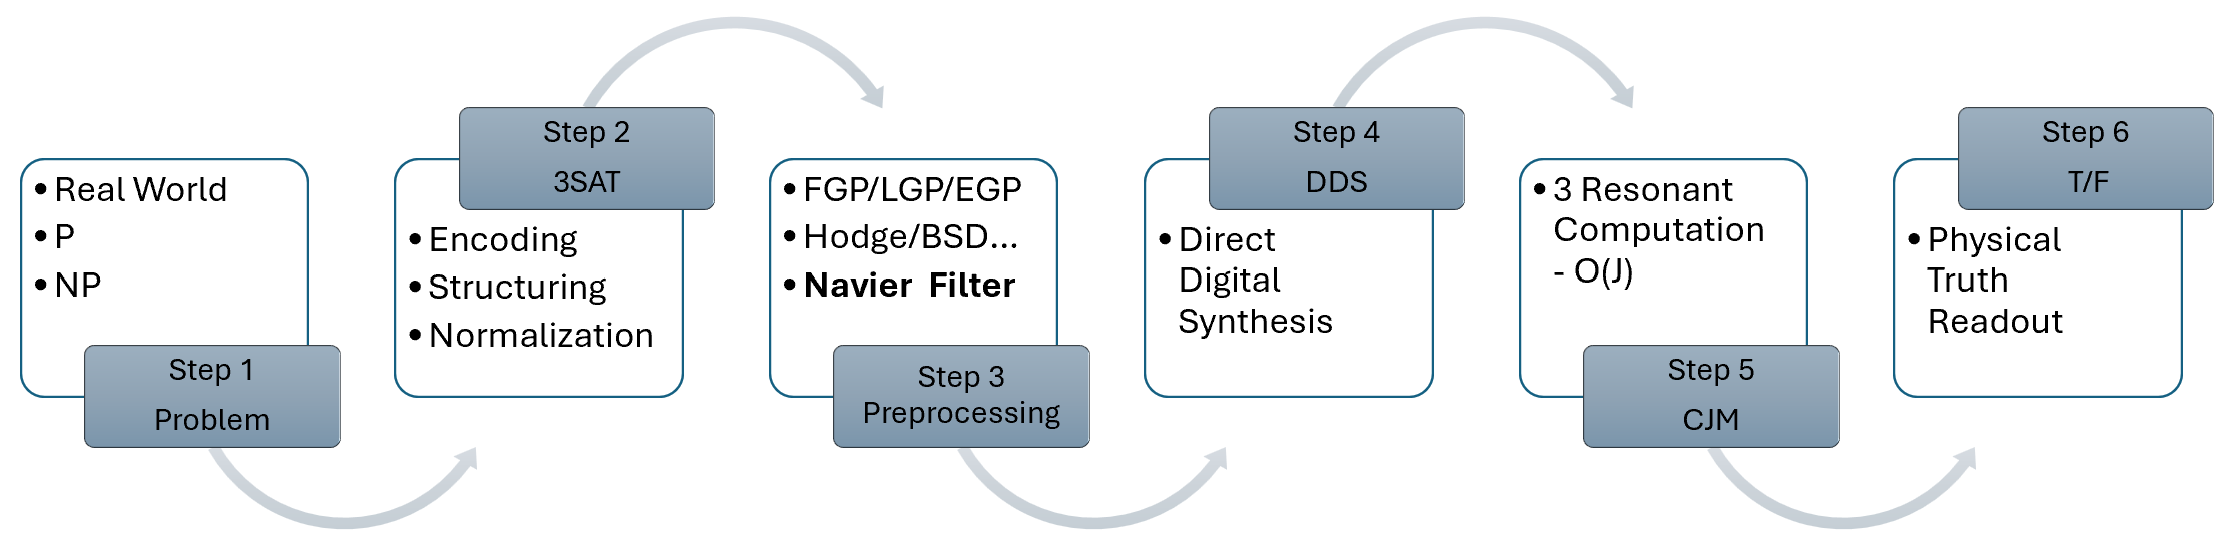

In [ ]:
# ============================================================
# Appendix 2: Conceptual Pseudocode for Navier Filter
# ============================================================
# This appendix provides conceptual pseudocode (not executable Python)
# for the CJM-Navier Filter. The purpose is not numerical simulation
# of the Navier--Stokes equations, but structural screening of a supplied
# flow state before deeper CJM stages.
#
# The Navier Filter is treated as an optional preprocessing-style gate:
#   (1) Flow-state signalization         -> instantaneous flow profile
#   (2) Vorticity--strain encoding       -> structural indicators
#   (3) 3SAT translation                 -> finite logical profile
#   (4) Persistence screening            -> residual structural support
#   (5) Admissibility scoring            -> Navier structural score
#   (6) Navier decision                  -> PASS / BORDERLINE / REJECT
#
# In recursive CJM usage, the input may be:
#   - a Navier--Stokes flow snapshot u(x,t0)
#   - a Navier structural indicator profile Theta_N
#   - a Navier-encoded 3SAT formula F
#   - a SAT-reduced instance F
#   - or an already encoded structural object Sigma_N
#
# The filter does not replace temporal Navier--Stokes evolution and is
# not a formal reduction of the full regularity problem to 3SAT.
# ============================================================

DEFINE TINY_THRESHOLD = small positive constant
DEFINE TAU_HIGH = high admissibility threshold
DEFINE TAU_LOW  = low admissibility threshold


# ==========================================
# STEP 1: INPUT MODULE (flow-state signalization)
# ==========================================
PROCEDURE step1_input_navier_filter(input_instance):

    # Interpret the input according to its current physical or logical form
    IF input_instance is FlowSnapshot u(x,t0):
        U <- ExtractInstantaneousFlowState(u(x,t0))
        Sigma_N <- BuildNavierStructuralRepresentation(U)

    ELSE IF input_instance is NavierIndicatorProfile Theta_N:
        Sigma_N <- LiftToNavierStructuralRepresentation(Theta_N)

    ELSE IF input_instance is Navier3SATFormula F:
        Sigma_N <- LiftToNavierStructuralRepresentation(F)

    ELSE IF input_instance is SATReducedInstance F:
        Sigma_N <- LiftToNavierStructuralRepresentation(F)

    ELSE:
        Sigma_N <- input_instance

    # Preserve only Navier-persistence-relevant information
    Preserve:
        - instantaneous velocity-field structure
        - incompressibility consistency
        - spatial neighborhood relations
        - vorticity organization
        - strain organization
        - Reynolds-number metadata
        - clause/indicator coupling structure

    RETURN Sigma_N


# ==========================================
# STEP 2: VORTICITY--STRAIN INDICATOR ENCODING
# ==========================================
PROCEDURE step2_vorticity_strain_encoding(Sigma_N):

    # Construct instantaneous physical indicators
    omega <- ComputeVorticity(Sigma_N)
    S <- ComputeStrainTensor(Sigma_N)

    # Vortex-stretching production
    P_omega <- Dot(
        omega,
        S * omega
    )

    # Positive viscous structural proxy
    D_omega <- nu * GradientNormSquared(omega)

    # Convert continuous indicators into structural literals
    x1 <- Indicator(
        P_omega > 0
    )

    x2 <- Indicator(
        D_omega >= max(P_omega, 0)
    )

    Theta_N <- BuildNavierIndicatorProfile(
        P_omega,
        D_omega,
        x1,
        x2
    )

    RETURN Theta_N


# ==========================================
# STEP 3: 3SAT TRANSLATION
# ==========================================
PROCEDURE step3_translate_to_3sat(Theta_N):

    # Translate the finite indicator profile into a logical structure
    # compatible with the common CJM interface
    F_N <- TranslateTo3SAT(Theta_N)

    # Local AND3 interaction used in the present probe
    FOR each structural index i:
        C_i <-
            x1[i]
            AND
            x2[i]
            AND
            x1[AdjacentPrevious(i)]
    END FOR

    AttachClauses(F_N, {C_i})

    # AdjacentPrevious(i) denotes spatial adjacency
    # within the same snapshot, not a previous time state.

    RETURN F_N


# ==========================================
# STEP 4: STRUCTURAL-PERSISTENCE SCREENING
# ==========================================
PROCEDURE step4_persistence_screening(F_N, Theta_N):

    # Evaluate whether distributed structural support remains organized
    # within the supplied instantaneous flow state
    control_fraction <- MeasureViscousControlFraction(Theta_N)

    clause_density <- MeasureAND3Density(F_N)

    spatial_persistence <- MeasurePersistentOrganization(F_N)

    fragmentation <- MeasureStructuralFragmentation(F_N)

    Check for:
        - broad loss of viscous-control support
        - concentration into localized residual regions
        - fragmentation of admissible spatial organization
        - persistence of coherent structural bands
        - excessive direction-dependent encoding sensitivity

    PersistenceProfile <- Combine(
        control_fraction,
        clause_density,
        spatial_persistence,
        fragmentation
    )

    RETURN PersistenceProfile


# ==========================================
# STEP 5: ADMISSIBILITY SCORING
# ==========================================
PROCEDURE step5_admissibility_scoring(
    F_N,
    PersistenceProfile
):

    # Pass the filtered structural profile through the fixed CJM core
    E <- FixedCJMCore(F_N)

    # Preserve the full admissibility texture
    M_J <- Mean(E)
    D_J <- StandardDeviation(E)
    F_J <- MedianCrossingFragmentation(E)

    NavierScore <-
          w1 * PersistenceProfile.control_fraction
        + w2 * PersistenceProfile.clause_density
        + w3 * PersistenceProfile.spatial_persistence
        - w4 * PersistenceProfile.fragmentation

    RETURN
        NavierScore,
        E,
        M_J,
        D_J,
        F_J


# ==========================================
# STEP 6: NAVIER FILTER DECISION
# ==========================================
PROCEDURE step6_navier_filter_decision(
    NavierScore,
    E
):

    # The decision concerns structural admissibility only.
    # It is not a declaration of smoothness, blow-up, or turbulence.
    IF NavierScore >= TAU_HIGH:
        verdict <- PASS

    ELSE IF NavierScore >= TAU_LOW:
        verdict <- BORDERLINE

    ELSE:
        verdict <- REJECT
    END IF

    RETURN verdict, NavierScore, E


# ==========================================
# MASTER CONTROL (CJM-Navier Filter)
# ==========================================
PROCEDURE run_CJM_Navier_Filter(
    input_instance,
    filter_enabled = TRUE
):

    # The Navier Filter is optional within the common CJM architecture
    IF filter_enabled == FALSE:
        ForwardToDeeperCJM(input_instance)
        RETURN BYPASS
    END IF

    # STEP 1
    Sigma_N <- step1_input_navier_filter(
        input_instance
    )

    # STEP 2
    Theta_N <- step2_vorticity_strain_encoding(
        Sigma_N
    )

    # STEP 3
    F_N <- step3_translate_to_3sat(
        Theta_N
    )

    # STEP 4
    PersistenceProfile <- step4_persistence_screening(
        F_N,
        Theta_N
    )

    # STEP 5
    NavierScore, E, M_J, D_J, F_J <-
        step5_admissibility_scoring(
            F_N,
            PersistenceProfile
        )

    # STEP 6
    verdict, NavierScore, E <-
        step6_navier_filter_decision(
            NavierScore,
            E
        )

    # Output to deeper CJM stages
    IF verdict == PASS:
        ForwardToDeeperCJM(
            F_N,
            E
        )

    ELSE IF verdict == BORDERLINE:
        FlagForReencodingOrAuxiliaryReview(
            F_N,
            E
        )

    ELSE:
        RejectAsStructurallyInadmissible(
            F_N
        )
    END IF

    RETURN
        verdict,
        NavierScore,
        E,
        M_J,
        D_J,
        F_J,
        PersistenceProfile